In [1]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_9729208cd66f2a74c2fb2c7437fef861"

os.makedirs('./data', exist_ok=True)

!kaggle datasets download -d evilspirit05/visdrone -p ./data

!unzip -q ./data/visdrone.zip -d ./data

Dataset URL: https://www.kaggle.com/datasets/evilspirit05/visdrone
License(s): MIT
100% 1.85G/1.85G [00:21<00:00, 92.8MB/s]



In [3]:
import os
import shutil

def flatten_and_setup():
    base_path = './data'
    splits = ['VisDrone2019-DET-train', 'VisDrone2019-DET-val']

    for split in splits:
        outer_split_path = os.path.join(base_path, split)
        inner_split_path = os.path.join(outer_split_path, split)

        if os.path.exists(inner_split_path):
            print(f'Flattening redundant folder: {inner_split_path}...')
            for item in os.listdir(inner_split_path):
                shutil.move(os.path.join(inner_split_path, item), os.path.join(outer_split_path, item))
            os.rmdir(inner_split_path)
            print(f'Successfully flattened {split}.')
        else:
            print(f'No nested folder found for {split}, skipping.')

flatten_and_setup()
!ls -F ./data/VisDrone2019-DET-val/

Flattening redundant folder: ./data/VisDrone2019-DET-train/VisDrone2019-DET-train...
Successfully flattened VisDrone2019-DET-train.
Flattening redundant folder: ./data/VisDrone2019-DET-val/VisDrone2019-DET-val...
Successfully flattened VisDrone2019-DET-val.
annotations/  images/


In [4]:
import os
import cv2

def convert_to_yolo():
    folders = ['VisDrone2019-DET-train', 'VisDrone2019-DET-val']
    base_path = './data'

    for folder_name in folders:
        img_dir = os.path.join(base_path, folder_name, 'images')
        label_dir = os.path.join(base_path, folder_name, 'annotations')
        output_dir = os.path.join(base_path, folder_name, 'labels') # YOLO expects 'labels'
        os.makedirs(output_dir, exist_ok=True)

        if not os.path.exists(label_dir):
            print(f'Skipping {folder_name}, annotations not found at {label_dir}.')
            continue

        print(f'Converting {folder_name} to YOLO format...')
        for label_file in os.listdir(label_dir):
            if not label_file.endswith('.txt'): continue

            img_path = os.path.join(img_dir, label_file.replace('.txt', '.jpg'))
            img = cv2.imread(img_path)
            if img is None: continue
            h_img, w_img, _ = img.shape

            yolo_data = []
            with open(os.path.join(label_dir, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split(',')
                    if len(parts) < 8: continue
                    x, y, w, h, score, category = map(int, parts[:6])
                    if category == 0 or category == 11: continue
                    class_id = category - 1
                    x_center = (x + w / 2) / w_img
                    y_center = (y + h / 2) / h_img
                    w_norm = w / w_img
                    h_norm = h / h_img
                    yolo_data.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")

            with open(os.path.join(output_dir, label_file), 'w') as f_out:
                f_out.write('\n'.join(yolo_data))

    print('Conversion complete. YOLO labels are in the "labels" folders.')

convert_to_yolo()

Converting VisDrone2019-DET-train to YOLO format...
Converting VisDrone2019-DET-val to YOLO format...
Conversion complete. YOLO labels are in the "labels" folders.


In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.9 MB/s eta 0:00:00


In [6]:
import yaml

data_config = {
    'path': '/content/data',
    'train': 'VisDrone2019-DET-train/images',
    'val': 'VisDrone2019-DET-val/images',
    'names': {
        0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van',
        5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'
    }
}

with open('visdrone.yaml', 'w') as f:
    yaml.dump(data_config, f)

print('visdrone.yaml updated.')

visdrone.yaml updated.


In [7]:
from ultralytics import YOLO

# Initialize YOLOv11s model
model = YOLO('yolo11s.pt')

print("Model initialized and ready for training.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model initialized and ready for training.


In [10]:
import torch

# Check if GPU is available
if torch.cuda.is_available():
    print(f"GPU found: {torch.cuda.get_device_name(0)}")
    device_choice = 0
else:
    print("GPU not found. Please go to Runtime > Change runtime type and select T4 GPU.")
    device_choice = 'cpu'

train_args = {
    "data": "visdrone.yaml",
    "epochs": 30,
    "imgsz": 750,
    "batch": 16, # Auto-batch
    "device": device_choice,
    "workers": 2,
    "project": "visdrone_detect",
    "name": "yolo11s_visdrone",
    "exist_ok": False,
    "pretrained": True,
    "optimizer": "auto",
    "patience": 12,
    "save": True,
    "plots": True,
    "cache": False,
    "seed": 42
}

# Start training
results = model.train(**train_args)

# Validate after training
val_results = model.val(conf=0.25, iou=0.6, augment=True, plots=True, save=True)

GPU found: Tesla T4
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=750, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_visdrone3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=12,

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 46.4±22.7 MB/s, size: 123.0 KB)
val: Scanning /content/data/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 39.0Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Plotting labels to /content/runs/detect/visdrone_detect/yolo11s_visdrone3/labels.jpg... 
Image sizes 768 train, 768 val
Using 2 dataloader workers
Logging results to /content/runs/detect/visdrone_detect/yolo11s_visdrone3
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/30      13.2G      1.432       1.07     0.9287        646        768: 100% ━━━━━━━━━━━━ 405/405 1.7it/s 3:59
                 Class     Images  Insta

In [11]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        # Only show the first 3 files to keep output clean
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}... ({len(files)} files total)')

if os.path.exists('./data'):
    list_files('./data')
else:
    print('The ./data directory does not exist.')

data/
    yolov9_finetuned.pt
    new_data.yaml
    data.yaml
    ... (4 files total)
    VisDrone2019-DET-test-dev/
        annotations/
            9999952_00000_d_0000304.txt
            9999952_00000_d_0000269.txt
            9999938_00000_d_0000310.txt
            ... (1610 files total)
        images/
            0000006_01111_d_0000003.jpg
            9999952_00000_d_0000221.jpg
            9999938_00000_d_0000227.jpg
            ... (1610 files total)
    VisDrone2019-DET-val/
        labels.cache
        labels/
            0000153_00401_d_0000001.txt
            0000117_03096_d_0000091.txt
            0000024_01000_d_0000014.txt
            ... (548 files total)
        annotations/
            0000153_00401_d_0000001.txt
            0000117_03096_d_0000091.txt
            0000024_01000_d_0000014.txt
            ... (548 files total)
        images/
            0000280_01201_d_0000618.jpg
            0000289_01401_d_0000818.jpg
            0000026_03000_d_0000030.jpg
        

In [12]:
# Export the model to ONNX format
path = model.export(format='onnx')
print(f"Model exported to: {path}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/visdrone_detect/yolo11s_visdrone3/weights/best.pt' with input shape (1, 3, 768, 768) BCHW and output shape(s) (1, 14, 12096) (18.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 539ms
Prepared 4 packages in 4.41s
Installed 4 packages in 318ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 6.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅


image 1/1 /content/data/VisDrone2019-DET-val/images/0000335_02745_d_0000057.jpg: 448x768 7 pedestrians, 14 peoples, 28 cars, 1 van, 3 tricycles, 13 motors, 54.7ms
Speed: 2.4ms preprocess, 54.7ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 768)


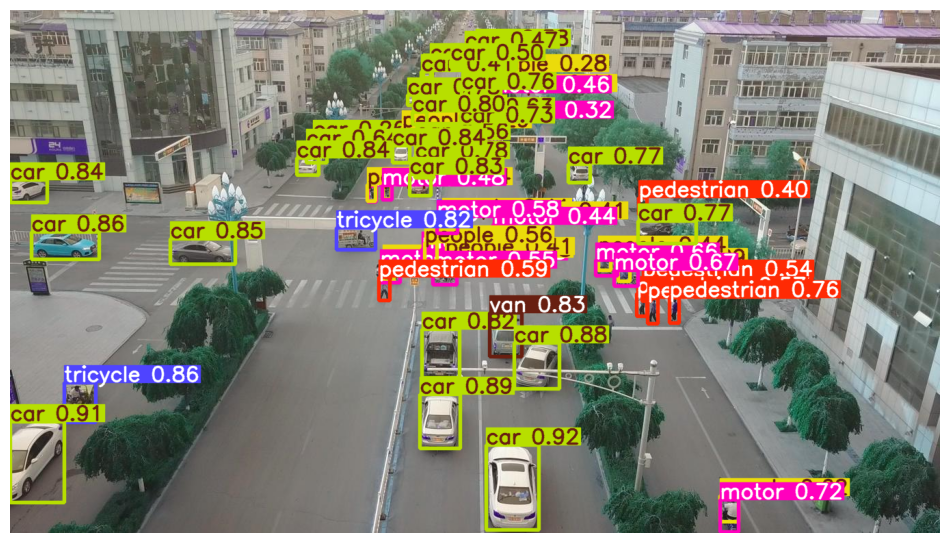

In [13]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Note: VisDrone test set folder name
test_img_dir = './data/VisDrone2019-DET-val/images'

test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
random_test_img = random.choice(test_images)

# Run inference
inference_results = model(random_test_img, conf=0.25)

# Show results
for result in inference_results:
    res_plotted = result.plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(res_plotted)
    plt.axis('off')
    plt.show()

In [14]:
import shutil
from google.colab import files

# Zip the entire runs directory
shutil.make_archive('visdrone_training_results', 'zip', 'runs')

# Download the zip file
files.download('visdrone_training_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import yaml

# Update yaml to include test path if not present
with open('visdrone.yaml', 'r') as f:
    config = yaml.safe_load(f)

config['test'] = 'VisDrone2019-DET-test-dev/images'

with open('visdrone.yaml', 'w') as f:
    yaml.dump(config, f)

print("Updated visdrone.yaml with test path.")

Updated visdrone.yaml with test path.


In [17]:
# Run evaluation on the validation set (which has ground truth labels)
test_results = model.val(
    data='visdrone.yaml',
    split='val',
    imgsz=750,
    conf=0.001,
    iou=0.6,
    project='visdrone_detect',
    name='yolo11s_val_eval'
)

print("\nValidation Scores (mAP50, mAP50-95):")
print(f"{test_results.results_dict['metrics/mAP50(B)']:.4f}, {test_results.results_dict['metrics/mAP50-95(B)']:.4f}")

WARNING ⚠️ imgsz=[750] must be multiple of max stride 32, updating to [768]
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2912.8±436.7 MB/s, size: 231.2 KB)
val: Scanning /content/data/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 176.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.6it/s 13.6s
                   all        548      38759      0.539      0.436      0.448       0.27
            pedestrian        520       8844      0.575      0.482      0.509      0.239
                people        482       5125      0.597      0.344      0.397      0.154
               bicycle        364       1287      0.292      0.238      0.184     0.0835
                   car        515      14064      0.751      0.816      0.836      0.599
                   van        421     